<a href="https://colab.research.google.com/github/xiaofei-builds/self-driving-rover/blob/main/notebooks/train_pilotnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi

Thu Aug  6 01:03:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
!ls -l /content/drive/MyDrive/xiaofei-builds/

Mounted at /content/drive
total 254753
-rw------- 1 root root 83549661 Aug  6 00:24 dataset_s10.zip
-rw------- 1 root root 78706221 Aug  1 16:23 dataset_s9.zip
-rw------- 1 root root 98606146 Aug  6 00:31 dataset.zip
drwx------ 2 root root     4096 Jul 28 03:54 model


In [5]:
!unzip -l "/content/drive/MyDrive/xiaofei-builds/dataset.zip" | head
!rm -rf /content/dataset
!unzip -q -o "/content/drive/MyDrive/xiaofei-builds/dataset.zip" -d /content/dataset
!wc -l /content/dataset/labels.csv
!ls /content/dataset/data | wc -l

Archive:  /content/drive/MyDrive/xiaofei-builds/dataset.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-08-06 00:07   data/
     7064  2026-07-27 04:35   data/img_002562.jpg
     5844  2026-07-27 04:37   data/img_003983.jpg
     6084  2026-07-27 04:35   data/img_002687.jpg
     6211  2026-07-30 04:47   data/img_007525.jpg
     7091  2026-07-27 04:39   data/img_005057.jpg
     6065  2026-07-27 04:35   data/img_002179.jpg
14698 /content/dataset/labels.csv
14697


In [6]:
import csv, numpy as np
from datetime import datetime

N, STRIDE, GAP_S = 4, 4, 0.5
need = (N-1)*STRIDE                     # 12 frames of history required
LAB  = "/content/dataset/labels.csv"

rows=[]
with open(LAB) as f:
    for r in csv.DictReader(f):
        t = datetime.fromisoformat(r["timestamp"]).timestamp()
        rows.append((t, r["image"], float(r["steering"])))
rows.sort(key=lambda x: x[0])
images = [r[1] for r in rows]
steer  = np.array([r[2] for r in rows], dtype=np.float32)
ts     = [r[0] for r in rows]

runs=[]; s=0
for i in range(1,len(rows)):
    if ts[i]-ts[i-1] > GAP_S:
        runs.append((s,i)); s=i
runs.append((s,len(rows)))

rng=np.random.default_rng(42)
val_runs=set(); acc=0; tot=len(rows)
for ri in rng.permutation(len(runs)):
    a,b=runs[ri]
    if acc < 0.2*tot:
        val_runs.add(int(ri)); acc += (b-a)

def build(run_ids):
    seqs=[]
    for ri in run_ids:
        a,b=runs[ri]
        for i in range(a+need,b):
            seqs.append([i-3*STRIDE, i-2*STRIDE, i-1*STRIDE, i])
    return np.array(seqs,dtype=np.int32)

train_ids=[ri for ri in range(len(runs)) if ri not in val_runs]
val_ids  =[ri for ri in range(len(runs)) if ri in val_runs]
seq_tr=build(train_ids); seq_va=build(val_ids)
print("frames",len(rows),"runs",len(runs),"val_runs",len(val_runs))
print("train seqs",len(seq_tr),"val seqs",len(seq_va))

frames 14697 runs 61 val_runs 13
train seqs 11111 val seqs 2892


In [7]:
import cv2
H,W = 120,160
frames = np.zeros((len(images),H,W,3), dtype=np.uint8)
for k,name in enumerate(images):
    img = cv2.imread("/content/dataset/data/"+name)   # BGR
    frames[k] = img[:, :, ::-1]                        # -> RGB (deploy contract)
print("frames", frames.shape, "%.2f GB"%(frames.nbytes/1e9))

frames (14697, 120, 160, 3) 0.85 GB


In [8]:
import tensorflow as tf, gc
frames_const = tf.constant(frames)      # uint8 ~0.72GB
del frames; gc.collect()                # drop the numpy duplicate

def make_stack(seq_idx):
    f = tf.gather(frames_const, seq_idx)
    f = tf.transpose(f,[1,2,0,3])
    f = tf.reshape(f,[H,W,N*3])
    return tf.cast(f,tf.float32)/255.0

def gen_ds(seqs, training):
    y  = (steer[seqs[:,3]]/30.0).astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((seqs, y))
    if training:
        ds = ds.shuffle(len(seqs), reshuffle_each_iteration=True)  # shuffle TINY indices
    ds = ds.map(lambda s,l:(make_stack(s),l), num_parallel_calls=4)
    if training:
        def aug(x,l):
            x = tf.image.random_brightness(x,0.2)
            x = tf.image.random_contrast(x,0.8,1.2)
            x = tf.clip_by_value(x,0.,1.)
            do = tf.random.uniform([])<0.5
            x = tf.cond(do, lambda: tf.image.flip_left_right(x), lambda: x)
            l = tf.cond(do, lambda: -l, lambda: l)
            return x,l
        ds = ds.map(aug, num_parallel_calls=4)
    return ds.batch(64).prefetch(2)

train_ds = gen_ds(seq_tr, True)
val_ds   = gen_ds(seq_va, False)
print("one batch:", next(iter(train_ds))[0].shape)

one batch: (64, 120, 160, 12)


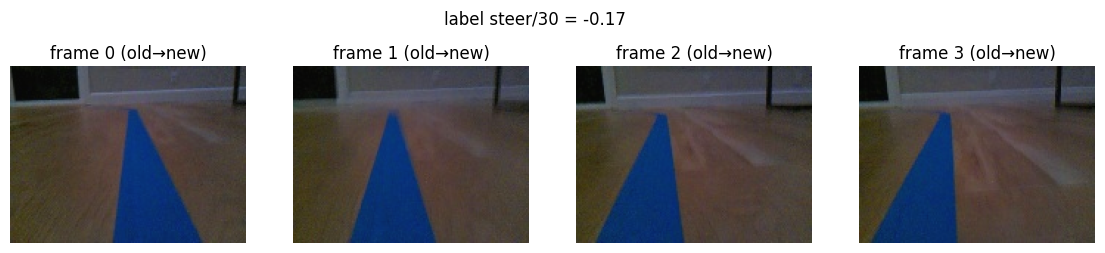

In [9]:
import matplotlib.pyplot as plt
xb,yb = next(iter(train_ds))
x0 = xb[0].numpy()
fig,ax = plt.subplots(1,4,figsize=(14,3))
for j in range(4):
    ax[j].imshow(x0[:,:,j*3:j*3+3]); ax[j].set_title(f"frame {j} (old→new)"); ax[j].axis('off')
plt.suptitle(f"label steer/30 = {yb[0].numpy():.2f}")
plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(120, 160, 12)),
    layers.Conv2D(24, 5, strides=2, activation='relu'),
    layers.Conv2D(32, 5, strides=2, activation='relu'),
    layers.Conv2D(64, 5, strides=2, activation='relu'),
    layers.Conv2D(64, 3, strides=2, activation='relu'),
    layers.Conv2D(64, 3, strides=1, activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(50, activation='relu'),
    layers.Dense(1)                      # linear output = steering
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 58, 78, 24)     │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 37, 32)     │        19,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 17, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,977 (1.04 MB)

 Trainable params: 271,977 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cb = tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')
hist = model.fit(train_ds, validation_data=val_ds, epochs=60, callbacks=[cb])

Epoch 1/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - loss: 0.0970 - mae: 0.2137 - val_loss: 0.0733 - val_mae: 0.1803
Epoch 2/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0678 - mae: 0.1667 - val_loss: 0.0517 - val_mae: 0.1433
Epoch 3/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0541 - mae: 0.1458 - val_loss: 0.0627 - val_mae: 0.1487
Epoch 4/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - loss: 0.0522 - mae: 0.1418 - val_loss: 0.0423 - val_mae: 0.1293
Epoch 5/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - loss: 0.0481 - mae: 0.1362 - val_loss: 0.0351 - val_mae: 0.1200
Epoch 6/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0465 - mae: 0.1335 - val_loss: 0.0454 - val_mae: 0.1267
Epoch 7/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - loss: 0.0421 - mae: 0.1273 - val_loss: 0.0495 - val_mae: 0.1287
Epoch 8/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - loss: 0.0408 - mae: 0.1248 - val_loss: 0.0379 - val_mae: 0.1170
Epoch 9/60
174/174 ━━━━━━━━━━━━━━━━━━━━

In [13]:
import numpy as np
xb, yb = next(iter(val_ds))
pred = model.predict(xb, verbose=0)[:,0]
true = yb.numpy()
order = np.argsort(-np.abs(true))
print(" true    pred")
for i in order[:10]:
    print(f"{true[i]*30:+6.1f}°  {pred[i]*30:+6.1f}°")


 true    pred
 +20.0°   +20.9°
 +20.0°   +21.4°
 +20.0°   +21.0°
 +20.0°   +21.1°
 +20.0°   +20.6°
 +20.0°   +19.3°
 +20.0°   +21.7°
 +15.0°   +21.8°
 +15.0°   +21.5°
 +15.0°    +9.6°


In [15]:
import numpy as np
P, T = [], []
for xb, yb in val_ds:
    P.append(model.predict(xb, verbose=0)[:,0]); T.append(yb.numpy())
P = np.concatenate(P)*30; T = np.concatenate(T)*30
order = np.argsort(-np.abs(T))
print(" true    pred")
for i in order[:15]:
    print(f"{T[i]:+6.1f}  {P[i]:+6.1f}")

 true    pred
 -30.0   -15.9
 -30.0   -17.2
 -30.0   -14.3
 -30.0   -15.2
 -30.0    -5.0
 -30.0    +0.8
 -30.0    +7.0
 -30.0    +5.7
 -30.0   -25.1
 -30.0   -20.8
 -30.0   -12.7
 -30.0   -15.8
 -30.0   -10.3
 -30.0   +15.0
 -30.0    +3.2


In [14]:
import numpy as np
P, T = [], []
for xb, yb in val_ds:
    P.append(model.predict(xb, verbose=0)[:, 0]); T.append(yb.numpy())
P = np.concatenate(P) * 30; T = np.concatenate(T) * 30

order = np.argsort(-np.abs(T))
print(" true    pred   (hardest turns across ALL val)")
for i in order[:15]:
    print(f"{T[i]:+6.1f}  {P[i]:+6.1f}")

print("\ncommit ratio by bucket (1.0 = commits, <1 softens, >1 over-steers)")
for lo, hi in [(25, 31), (15, 25), (5, 15)]:
    m = (np.abs(T) >= lo) & (np.abs(T) < hi)
    if m.sum():
        print(f"|true| {lo}-{hi}: n={m.sum():4d}  ratio={np.mean(np.abs(P[m])/np.abs(T[m])):.2f}")

 true    pred   (hardest turns across ALL val)
 -30.0   -15.9
 -30.0   -17.2
 -30.0   -14.3
 -30.0   -15.2
 -30.0    -5.0
 -30.0    +0.8
 -30.0    +7.0
 -30.0    +5.7
 -30.0   -25.1
 -30.0   -20.8
 -30.0   -12.7
 -30.0   -15.8
 -30.0   -10.3
 -30.0   +15.0
 -30.0    +3.2

commit ratio by bucket (1.0 = commits, <1 softens, >1 over-steers)
|true| 25-31: n= 101  ratio=0.65
|true| 15-25: n= 955  ratio=0.86
|true| 5-15: n=1268  ratio=0.93


In [16]:
conv = tf.lite.TFLiteConverter.from_keras_model(model)
tfl  = conv.convert()
open("/content/pilot_stateful.tflite","wb").write(tfl)

# verify tflite == keras to the decimal
xb,yb = next(iter(val_ds)); x1 = xb[:1].numpy()
k = model.predict(x1, verbose=0)[0,0]
itp = tf.lite.Interpreter(model_content=tfl); itp.allocate_tensors()
ind=itp.get_input_details()[0]; outd=itp.get_output_details()[0]
itp.set_tensor(ind['index'], x1); itp.invoke()
t = itp.get_tensor(outd['index'])[0,0]
print("tflite input shape", ind['shape'])
print(f"keras {k:.5f}  tflite {t:.5f}  diff {abs(k-t):.2e}")

import shutil, os
os.makedirs("/content/drive/MyDrive/xiaofei-builds/model", exist_ok=True)
shutil.copy("/content/pilot_stateful.tflite","/content/drive/MyDrive/xiaofei-builds/model/pilot_stateful.tflite")
model.save("/content/drive/MyDrive/xiaofei-builds/model/pilot_stateful.keras")
print("saved to Drive/model/pilot_stateful.*")


Saved artifact at '/tmp/tmp_fv0fi30'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 160, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134068678901200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068678900048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068634306320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068634307280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068678901392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068678900624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068634305360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068634306128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068634306704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134068634307664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1340686343078

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


tflite input shape [  1 120 160  12]
keras 0.06009  tflite 0.06009  diff 2.61e-08
saved to Drive/model/pilot_stateful.*
